# Video Game Commercial Success Prediction & Market Analysis

The goal of this project is to deliver a clear commercial narrative that game studios and publishers can use to minimize financial risk before greenlighting a new game's production.

When looking into creating new games studios and publishers investigate what has been historically successful. By analyzing characteristics of games that have already been released, we can help guide new game ideas to the right publishers to help propagate the game to a better sales pattern, allowing both the publisher and game developer to maximize their investment.

#### 1. Imports & Data Loading

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SQL alchemy
from sqlalchemy import create_engine, text

# scikitlearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.dummy import DummyClassifier

In [49]:
# create in-memory SQLite database
engine = create_engine('sqlite:///:memory:')

In [50]:
# load raw data
df_raw = pd.read_csv('datasets/Video_Games_Sales.csv')

In [51]:
# ingest raw data into database
df_raw.to_sql('raw_game_sales', con=engine, index=False, if_exists='replace')

16719

In [52]:
# run wuery against database to confirm ingestion
query = """
SELECT count(*)
FROM raw_game_sales
"""

In [53]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    print(f'Successfully ingested {results.scalar()} records into in-memory table "raw_game_sales".')

Successfully ingested 16719 records into in-memory table "raw_game_sales".


In [54]:
# pull data from database to pandas DataFrame
query = """
SELECT platform as platform,
    year_of_release as release_year,
    genre as genre,
    publisher as publisher,
    global_sales as global_sales
FROM raw_game_sales
WHERE global_sales IS NOT NULL
AND year_of_release IS NOT NULL
AND publisher IS NOT NULL;
"""

In [55]:
with engine.connect() as conn:
    results = conn.execute(text(query))
    df_pulled = pd.DataFrame(results)

In [56]:
df_pulled.info()

<class 'pandas.DataFrame'>
RangeIndex: 16418 entries, 0 to 16417
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   platform      16418 non-null  str    
 1   release_year  16418 non-null  float64
 2   genre         16416 non-null  str    
 3   publisher     16418 non-null  str    
 4   global_sales  16418 non-null  float64
dtypes: float64(2), str(3)
memory usage: 641.5 KB


#### 2. Data Cleaning & Target Creation

In [57]:
# drop missing values
df_clean = df_pulled.dropna(subset='genre').copy()

In [58]:
# parse release_year to 'int' from 'float64'
df_clean['release_year'] = df_clean['release_year'].astype(int)

##### Create Dynamic Target

In [59]:
# top 20% global sales within each release year
df_clean['year_80th_p'] = df_clean.groupby('release_year')['global_sales'].transform(lambda x: x.quantile(0.80))
df_clean['is_hit'] = (df_clean['global_sales'] >= df_clean['year_80th_p']).astype(int)

In [60]:
# reduction of publisher cardinality
top_publishers = df_clean['publisher'].value_counts().nlargest(15).index
df_clean['publisher_grouped'] = df_clean['publisher'].apply(lambda x: x if x in top_publishers else 'Other')

In [61]:
# get top platforms
nin = 'nintendo'
pl = 'playstation'
xb = 'xbox'
platform_map = {
    'PS': pl, 'PS2': pl, 'PS2': pl, 'PS3': pl, 'PS4': pl, 'PSP': pl, 'PSV': pl,
    'XB': xb, 'X360': xb, 'XOne': xb,
    'Wii': nin, 'WiiU': nin, 'DS': nin, '3DS': nin, 'GBA': nin, 'GB': nin, 'GC': nin, 'N64': nin
}

df_clean['platform_family'] = df_clean['platform'].map(platform_map).fillna('Other')

In [62]:
print(f'Cleaned dataset shape: {df_clean.shape}')
print(f'Target Distribution (is_hit): \n', df_clean['is_hit'].value_counts(normalize=True))

Cleaned dataset shape: (16416, 9)
Target Distribution (is_hit): 
 is_hit
0    0.797636
1    0.202364
Name: proportion, dtype: float64


#### 3. Feature Selection & Train/Test Split

In [63]:
# Strictly pre-release features to prevent target leakage
features = ['platform_family', 'genre', 'publisher_grouped', 'release_year']

In [64]:
# temporal time split
cutoff_year = 2013

train_mask = df_clean['release_year'] < cutoff_year
test_mask = df_clean['release_year'] >= cutoff_year

X = df_clean[features]
y = df_clean['is_hit']

X_train = df_clean.loc[train_mask, features]
y_train = df_clean.loc[train_mask, 'is_hit']

X_test = df_clean.loc[test_mask, features]
y_test = df_clean.loc[test_mask, 'is_hit']


#### 4. Preprocessing & Model Training, Baseline Comparison & Probability Evaluation

In [65]:
categorical_features = ['platform_family', 'genre', 'publisher_grouped']
numeric_features = ['release_year']

In [66]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)
    ]
)

In [67]:
models = {
    'Dummy Classifier': DummyClassifier(strategy='stratified', random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'HistGradient Boosting': HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
}

In [68]:
fitted_pipelines = {}

In [69]:
print('--- 5-Fold Cross-Validation (ROC-AUC) ---')

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # fit on training data and store pipeline
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline

    cv_score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')

    print(f'{name} -> Mean ROC-AUC: {cv_score.mean():.4f} (+- {cv_score.std():.4f})')

--- 5-Fold Cross-Validation (ROC-AUC) ---
Dummy Classifier -> Mean ROC-AUC: 0.5122 (+- 0.0004)
LogisticRegression -> Mean ROC-AUC: 0.7316 (+- 0.0457)
HistGradient Boosting -> Mean ROC-AUC: 0.7371 (+- 0.0303)


### 5. Test Set Evaluation & Metrics (Precision, Recall, F1, ROC-AUC)

In [70]:
for name, pipeline in fitted_pipelines.items():
    if name == 'Dummy Classifier':
        continue

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    auc_score = roc_auc_score(y_test, y_proba)

    print(f'--- Model: {name} ---')
    print(f'Test ROC-AUC Score: {auc_score:.4f} (Target: >= 0.75)')
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred))

--- Model: LogisticRegression ---
Test ROC-AUC Score: 0.8093 (Target: >= 0.75)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1779
           1       0.42      0.74      0.54       456

    accuracy                           0.74      2235
   macro avg       0.67      0.74      0.68      2235
weighted avg       0.82      0.74      0.76      2235

--- Model: HistGradient Boosting ---
Test ROC-AUC Score: 0.8213 (Target: >= 0.75)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.80      1779
           1       0.40      0.77      0.52       456

    accuracy                           0.71      2235
   macro avg       0.66      0.73      0.66      2235
weighted avg       0.81      0.71      0.74      2235



### 6. Interpretability: Logistic Regression Odds Ratios

In [71]:
# Logistic Regression Model
log_reg_model = fitted_pipelines['LogisticRegression'].named_steps['classifier']

# onehotencoder feature names
ohe_feature_names = fitted_pipelines['LogisticRegression'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_feature_names)

odd_ratios = pd.DataFrame({
    'feature': all_feature_names,
    'coef': log_reg_model.coef_[0],
    'odds_ratio': np.exp(log_reg_model.coef_[0])
    }).sort_values(by='odds_ratio', ascending=False)

print('--- Top 10 Positive Drivers of Commercial Hits (Odds Ratios) ---')
print(odd_ratios.head(10).to_string(index=False))


--- Top 10 Positive Drivers of Commercial Hits (Odds Ratios) ---
                                                 feature     coef  odds_ratio
                              publisher_grouped_Nintendo 1.836716    6.275897
                       publisher_grouped_Electronic Arts 0.851818    2.343905
                           publisher_grouped_Square Enix 0.675412    1.964842
                                           genre_Shooter 0.402299    1.495258
                                          genre_Fighting 0.402154    1.495041
                                    platform_family_xbox 0.343863    1.410386
publisher_grouped_Warner Bros. Interactive Entertainment 0.326538    1.386161
                             platform_family_playstation 0.323858    1.382451
                                          genre_Platform 0.319159    1.375969
                                      genre_Role-Playing 0.318386    1.374907


### Visualizations: Heatmap & Confusion Matrix

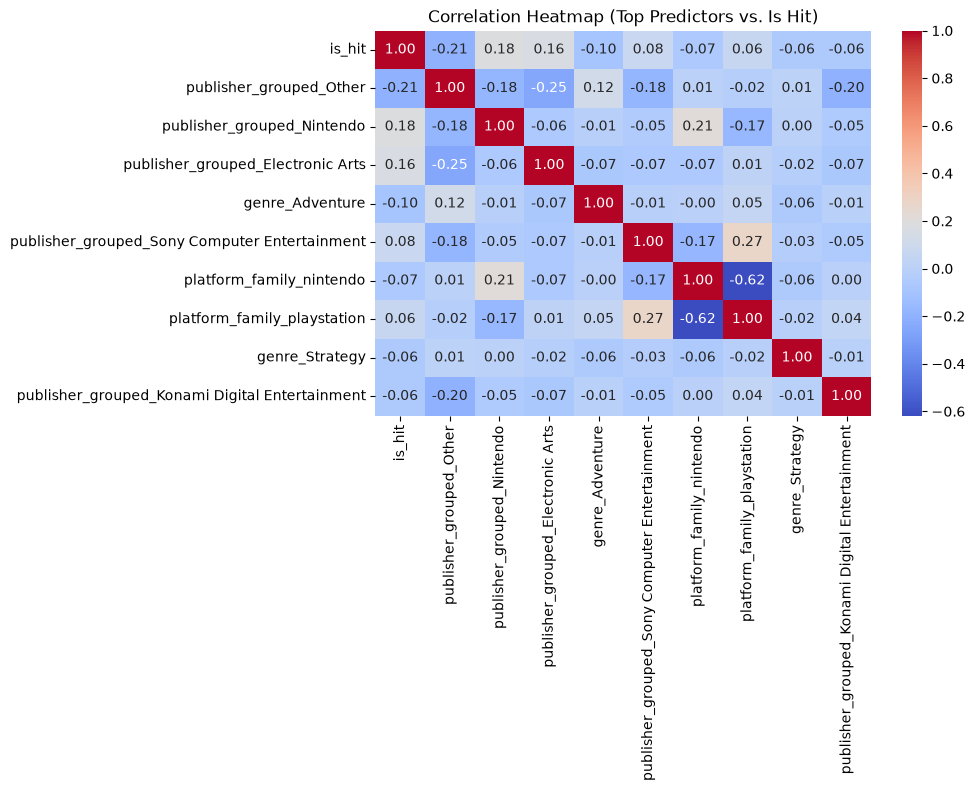

In [75]:

X_train_encoded = fitted_pipelines['LogisticRegression'].named_steps['preprocessor'].transform(X_train)
df_encoded = pd.DataFrame(X_train_encoded, columns=all_feature_names)
df_encoded['is_hit'] = y_train.values

top_corr_features = df_encoded.corr()['is_hit'].abs().nlargest(10).index

plt.figure(figsize=(8, 5))

corr_map = sns.heatmap(df_encoded[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
corr_map.set_title('Correlation Heatmap (Top Predictors vs. Is Hit)')

plt.show()

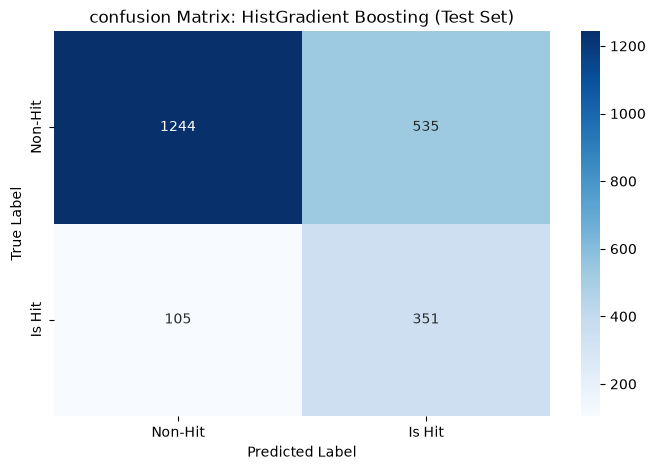

In [80]:
# Confusion Matrix

best_model = fitted_pipelines['HistGradient Boosting']
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 5))

hgb_matrix = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Hit', 'Is Hit'],
    yticklabels=['Non-Hit', 'Is Hit'],
)

hgb_matrix.set_title('confusion Matrix: HistGradient Boosting (Test Set)')
hgb_matrix.set_xlabel('Predicted Label')
hgb_matrix.set_ylabel('True Label')

plt.show()

In [102]:
# adjusted threshold to fine tune false positives/negatives
y_proba = fitted_pipelines['HistGradient Boosting'].predict_proba(X_test)[:, 1]

custom_threshold = 0.65
y_pred_tuned = (y_proba >= custom_threshold).astype(int)

print(f'--- Performance at Threshold = {custom_threshold} ---')
print(classification_report(y_test, y_pred_tuned))


--- Performance at Threshold = 0.65 ---
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      1779
           1       0.51      0.64      0.57       456

    accuracy                           0.80      2235
   macro avg       0.70      0.74      0.72      2235
weighted avg       0.82      0.80      0.81      2235



confusion_matrix:


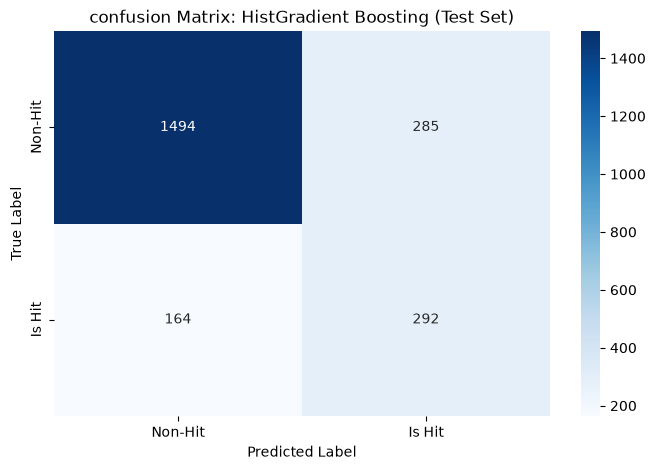

In [103]:
print('confusion_matrix:')
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 5))

hgb_matrix = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Hit', 'Is Hit'],
    yticklabels=['Non-Hit', 'Is Hit'],
)

hgb_matrix.set_title('confusion Matrix: HistGradient Boosting (Test Set)')
hgb_matrix.set_xlabel('Predicted Label')
hgb_matrix.set_ylabel('True Label')

plt.show()

In [98]:
from sklearn.metrics import precision_recall_curve, roc_curve

# 1. Extract predicted probabilities for the positive class (Hit)
y_proba = fitted_pipelines['HistGradient Boosting'].predict_proba(X_test)[:, 1]

# 2. Find optimal threshold based on Maximum F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_f1_idx = np.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_idx]
best_f1_score = f1_scores[best_f1_idx]

# 3. Find optimal threshold based on Youden's J Statistic (ROC Curve)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr

best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

print("="*50)
print("AUTOMATED THRESHOLD OPTIMIZATION RESULTS")
print("="*50)
print(f"Optimal Threshold for Max F1-Score: {best_f1_threshold:.4f}")
print(f"  -> Highest Achievable F1-Score: {best_f1_score:.4f}")
print(f"  -> Associated Precision:         {precisions[best_f1_idx]:.4f}")
print(f"  -> Associated Recall:            {recalls[best_f1_idx]:.4f}")
print("-" * 50)
print(f"Optimal Threshold for Youden's J:  {best_j_threshold:.4f}")

AUTOMATED THRESHOLD OPTIMIZATION RESULTS
Optimal Threshold for Max F1-Score: 0.6294
  -> Highest Achievable F1-Score: 0.5690
  -> Associated Precision:         0.5025
  -> Associated Recall:            0.6557
--------------------------------------------------
Optimal Threshold for Youden's J:  0.4418


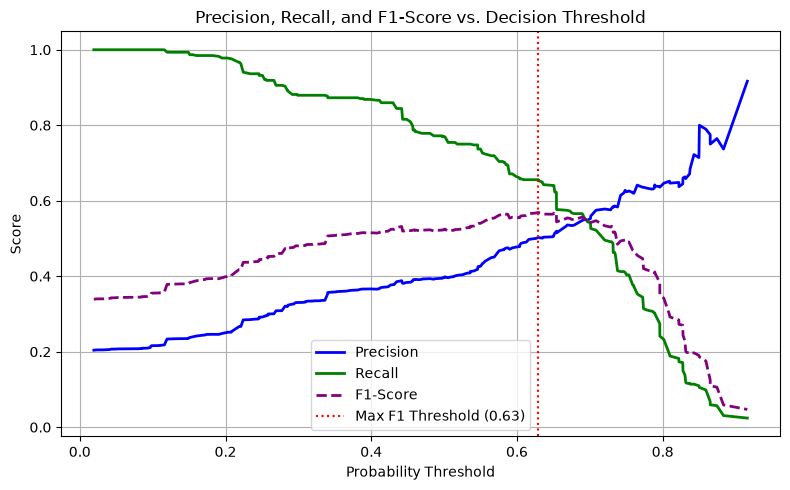

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall', color='green', lw=2)
plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='purple', linestyle='--', lw=2)

plt.axvline(x=best_f1_threshold, color='red', linestyle=':', label=f'Max F1 Threshold ({best_f1_threshold:.2f})')

plt.title('Precision, Recall, and F1-Score vs. Decision Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()